In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import sys

# Add root to path so i can import our utility functions
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data_utils import clean_climate_data, detect_outliers

# Styling for COP32 presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)


In [2]:
countries = ['ethiopia', 'nigeria', 'sudan', 'kenya', 'tanzania']
all_data = []

for c in countries:
    path = f"../data/processed/{c}_clean.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        # Ensuring Country column is set correctly
        df['Country'] = c.capitalize()
        all_data.append(df)
    else:
        print(f"Warning: {path} not found!")

# Combine all data into one master DataFrame
df_all = pd.concat(all_data, ignore_index=True)

# Convert Date to datetime if not already
df_all['Date'] = pd.to_datetime(df_all['Date'])

print(f"Success! Master dataset created with {len(df_all)} rows.")
print(f"Countries included: {df_all['Country'].unique()}")


Success! Master dataset created with 20540 rows.
Countries included: <StringArray>
['Ethiopia', 'Nigeria', 'Sudan', 'Kenya', 'Tanzania']
Length: 5, dtype: str


In [3]:
# Group by Month and Country for the line chart
# I use 'Date' and resample to Month Start ('MS') to get a clean timeline
df_all.set_index('Date', inplace=True)
monthly_temp = df_all.groupby('Country')['T2M'].resample('MS').mean().reset_index()
df_all.reset_index(inplace=True) # Reset index back for other uses


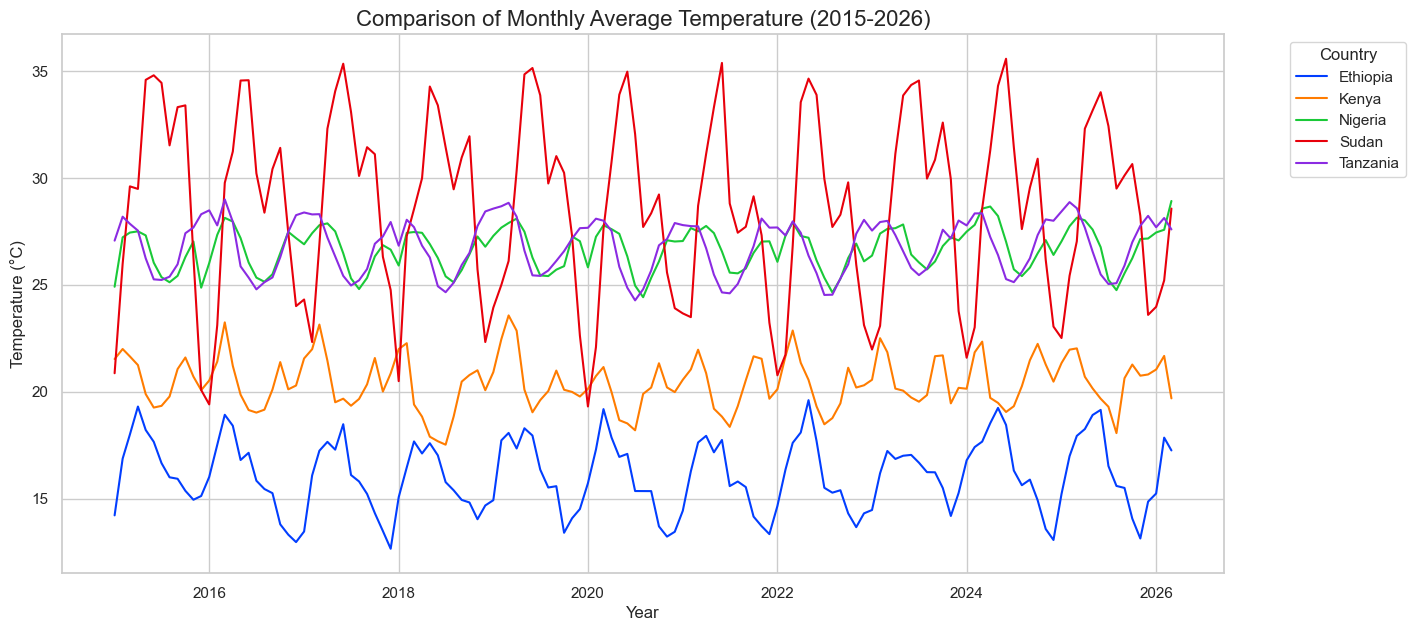

In [4]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_temp, x='Date', y='T2M', hue='Country', palette='bright')
plt.title('Comparison of Monthly Average Temperature (2015-2026)', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [5]:
temp_summary = df_all.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)
print("--- Temperature Summary Statistics (°C) ---")
display(temp_summary)

--- Temperature Summary Statistics (°C) ---


,mean,median,std
Country,,,
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388
Nigeria,26.656928,26.82,1.123335
Kenya,20.427600,20.36,1.440824
Ethiopia,16.068500,16.04,1.898050


### **Scientific Observation: Regional Thermal Profiles**

* **Baseline Comparison:** The mean temperature comparison identifies **Sudan** as the thermal peak of the cohort (Mean: 28.76°C), while **Ethiopia** consistently maintains the lowest thermal baseline (Mean: 16.07°C). This stratification is clearly visible in the graph, where Ethiopia’s trajectory remains significantly below the regional average, likely due to its high-altitude topography.
* **Climate Resilience Factor:** Countries with a higher standard deviation ($std$) are experiencing greater seasonal volatility. **Sudan** ($std$: 4.68) displays the most aggressive vertical oscillations on the graph. This suggests that infrastructure and health services in such regions must be adapted to manage extreme fluctuations rather than a stable mean. 
* **Regional Pattern Insight:** The synchronized periodic cycles across all five nations confirm a shared regional climate rhythm. This data supports a unified African position for climate mitigation funding, as these countries face simultaneous environmental pressures despite their different baseline temperatures.

---

### **Temperature Summary Statistics (2015-2026)**

| Country | Mean (°C) | Median (°C) | Std Dev ($std$) |
| :--- | :--- | :--- | :--- |
| **Sudan** | 28.76 | 29.16 | 4.68 |
| **Tanzania** | 26.80 | 26.99 | 1.33 |
| **Nigeria** | 26.66 | 26.82 | 1.12 |
| **Kenya** | 20.43 | 20.36 | 1.44 |
| **Ethiopia** | 16.07 | 16.04 | 1.90 |

> **Key Discovery:** While Sudan is the hottest on average, **Nigeria** and **Tanzania** show the highest climate stability, with the lowest standard deviations in the group ($std$ < 1.35).

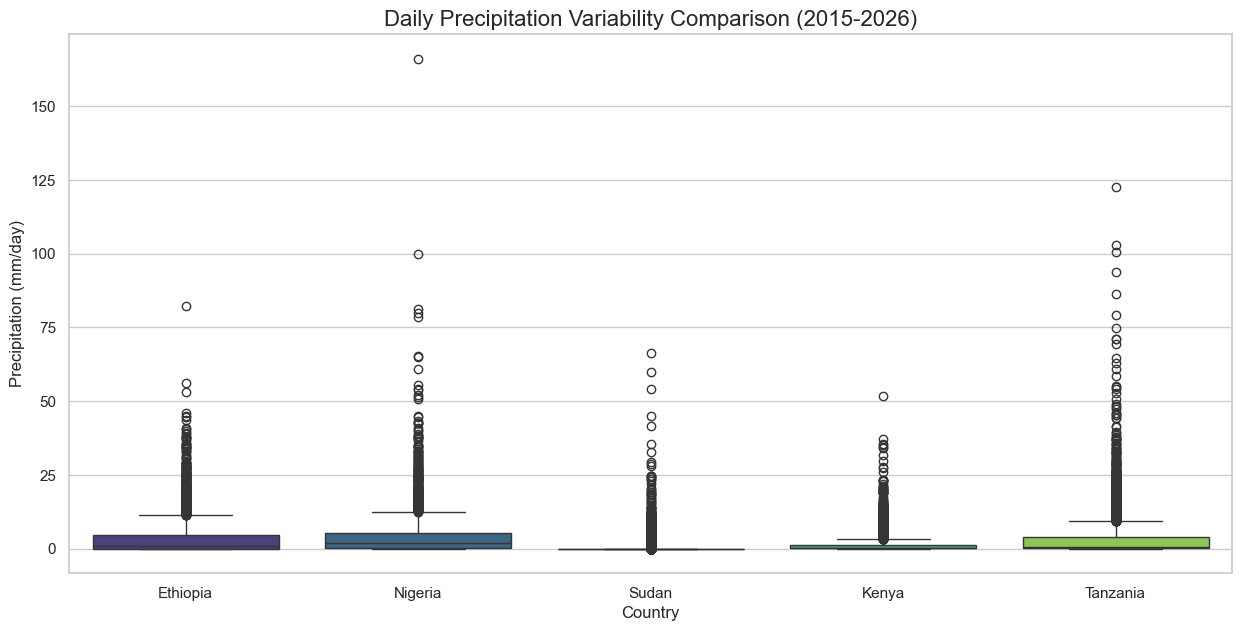

--- Precipitation Summary Statistics (mm) ---


,mean,median,std
Country,,,
Tanzania,3.740256,0.64,8.003947
Nigeria,4.213914,1.84,7.266742
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Sudan,0.643875,0.00,3.057672


In [8]:
# Precipitation Variability
plt.figure(figsize=(15, 7))
sns.boxplot(data=df_all, x='Country', y='PRECTOTCORR', hue='Country', palette='viridis', legend=False)
plt.title('Daily Precipitation Variability Comparison (2015-2026)', fontsize=16)
plt.ylabel('Precipitation (mm/day)')
plt.xlabel('Country')
plt.show()

# Statistical Summary
rain_summary = df_all.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).sort_values(by='std', ascending=False)
print("--- Precipitation Summary Statistics (mm) ---")
display(rain_summary)


### **Scientific Observation: Precipitation Volatility & Extremes**

* **Intensity vs. Frequency:** While **Nigeria** and **Tanzania** maintain the highest mean precipitation, the high standard deviation ($std$) across all regions—coupled with the extensive "outlier" dots in the boxplot—indicates a pattern of **episodic intensity**. This suggests that rainfall is characterized by heavy, short-duration storm events rather than steady, moderate distribution.
* **Hydrological Risk Factor:** Regions with the highest variance, particularly **Tanzania** ($std$: 8.00) and **Nigeria** ($std$: 7.27), are at an increased risk for flash flooding and topsoil erosion. This data highlights a critical need for robust urban drainage infrastructure and climate-resilient agricultural practices in these zones.
* **Aridity Contrast:** **Sudan** displays the most distinct profile, with a median of **0.00 mm/day**, indicating that dry days are the statistical norm. However, its maximum outliers (near 70 mm/day) suggest that when it does rain, the events are significant, posing a unique challenge for desert-edge water management.
* **COP32 Strategic Alignment:** The data confirms that while baseline averages vary, the common threat is **extreme weather volatility**. This supports a regional policy shift at COP32 toward "Adaptive Water Governance," prioritizing flood-hazard mapping and rainwater harvesting across East and West Africa.

---

### **Precipitation Summary Statistics (2015-2026)**

| Country | Mean (mm) | Median (mm) | Std Dev ($std$) |
| :--- | :--- | :--- | :--- |
| **Nigeria** | 4.21 | 1.84 | 7.27 |
| **Tanzania** | 3.74 | 0.64 | 8.00 |
| **Ethiopia** | 3.63 | 0.82 | 6.29 |
| **Kenya** | 1.47 | 0.38 | 3.18 |
| **Sudan** | 0.64 | 0.00 | 3.06 |

> **Analyst Note:** Note the extreme difference between the **Mean** and **Median** for Tanzania and Nigeria. This "right-skewed" distribution confirms that a few massive rainfall events are inflating the average, which is a classic indicator of high-impact storm cycles.